# CITADEL

## Scidocs

In [1]:
cd dpr-scale

bash dataset_prepare.sh
bash generate_embeddings.sh
bash merge_embeddings.sh
bash prune_embeddings.sh
bash quantize_embeddings.sh
bash Retrieval.sh
bash Evaluation.sh

SyntaxError: invalid syntax (1059002488.py, line 1)

In [ ]:
cd dpr-scale

bash beir_pipe_scidocs.sh

In [ ]:
$BASE_DIR/
├── embeddings/scidocs/               
├── merged_embeddings/scidocs/
│   ├── expert/                        
│   ├── expert_pruned0.5/
│   ├── expert_pruned0.5_pq_nbits2/
│   ├── expert_pruned0.7/
│   └── ...
├── retrieval/scidocs/
│   ├── pruned_0.5/
│   │   ├── retrieval.trec
│   │   └── performance/performance.yaml
│   ├── pruned_0.7/
│   └── ...
└── results/scidocs/
    ├── pruned_0.5/
    │   └── eval_results.txt
    ├── pruned_0.7/
    └── ...

In [ ]:
import os
import yaml
import csv
import re
from glob import glob

# 配置路径
BASE_DIR = "/data1/chenyifeng/MultiVector-Backup/dpr-scale"
DATASET = "scidocs"
pruning_weights = [0.5, 0.7, 0.9, 1.1, 1.3]

def parse_eval_results(file_path):
    """从 eval_results.txt 提取所有指标，返回字典"""

    metrics = {}
    if not os.path.exists(file_path):
        return metrics
    with open(file_path, 'r') as f:
        content = f.read()

    # 匹配形如 "NDCG@10: 0.1234" 的行
    pattern = re.compile(r'(\w+)@(\d+):\s+([\d.]+)')
    for match in pattern.finditer(content):
        metric_name = match.group(1).lower()
        k = match.group(2)
        value = float(match.group(3))
        key = f"{metric_name}_{k}"   # 例如 ndcg_10, map_100, recall_10, p_100
        metrics[key] = value
    return metrics

def parse_performance(file_path):
    """从 performance.yaml 读取所有字段，返回字典"""

    if not os.path.exists(file_path):
        return {}
    with open(file_path, 'r') as f:
        data = yaml.safe_load(f)
    return data

def main():
    all_rows = []
    for w in pruning_weights:
        # 直接使用权重值作为目录名（保留小数点）
        weight_str = str(w)   # 例如 "0.5"
        eval_file = os.path.join(BASE_DIR, "results", DATASET, f"pruned_{weight_str}", "eval_results.txt")
        perf_file = os.path.join(BASE_DIR, "retrieval", DATASET, f"pruned_{weight_str}", "performance", "performance.yaml")

        # 解析数据
        metrics = parse_eval_results(eval_file)
        perf = parse_performance(perf_file)

        # 合并数据（添加标识字段）
        row = {
            "dataset": DATASET,
            "split": "test",
            "baseline": "citadel",
            "pruning_weight": w,
            **perf,          # 展开 performance 中的所有键值
            **metrics        # 展开评估指标
        }
        all_rows.append(row)

    if not all_rows:
        print("No data found. Please check paths and pruning_weights.")
        return

    # 收集所有出现的列名（自动获取所有键的并集）
    all_fieldnames = set()
    for row in all_rows:
        all_fieldnames.update(row.keys())

    # 按顺序排列，将标识字段放在前面
    sorted_fields = ["dataset", "split", "baseline", "pruning_weight"]
    
    # 添加 performance 和 metrics 的其他字段，按字母排序
    other_fields = sorted([f for f in all_fieldnames if f not in sorted_fields])
    fieldnames = sorted_fields + other_fields

    # 写入 CSV
    output_dir = os.path.join(BASE_DIR, "results", DATASET)
    os.makedirs(output_dir, exist_ok=True)
    output_file = os.path.join(output_dir, "summary.csv")

    with open(output_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(all_rows)

    print(f"Summary CSV saved to: {output_file}")
    print(f"Columns: {fieldnames}")

if __name__ == "__main__":
    main()

Summary CSV saved to: /data1/chenyifeng/MultiVector-Backup/dpr-scale/results/scidocs/summary.csv
Columns: ['dataset', 'split', 'baseline', 'pruning_weight', 'batch_size', 'context_topk', 'cuda', 'elapsed_sec', 'map_10', 'map_100', 'ndcg_10', 'ndcg_100', 'p_10', 'p_100', 'portion', 'qps', 'quantizer', 'query_topk', 'recall_10', 'recall_100', 'sub_vec_dim', 'total_queries']


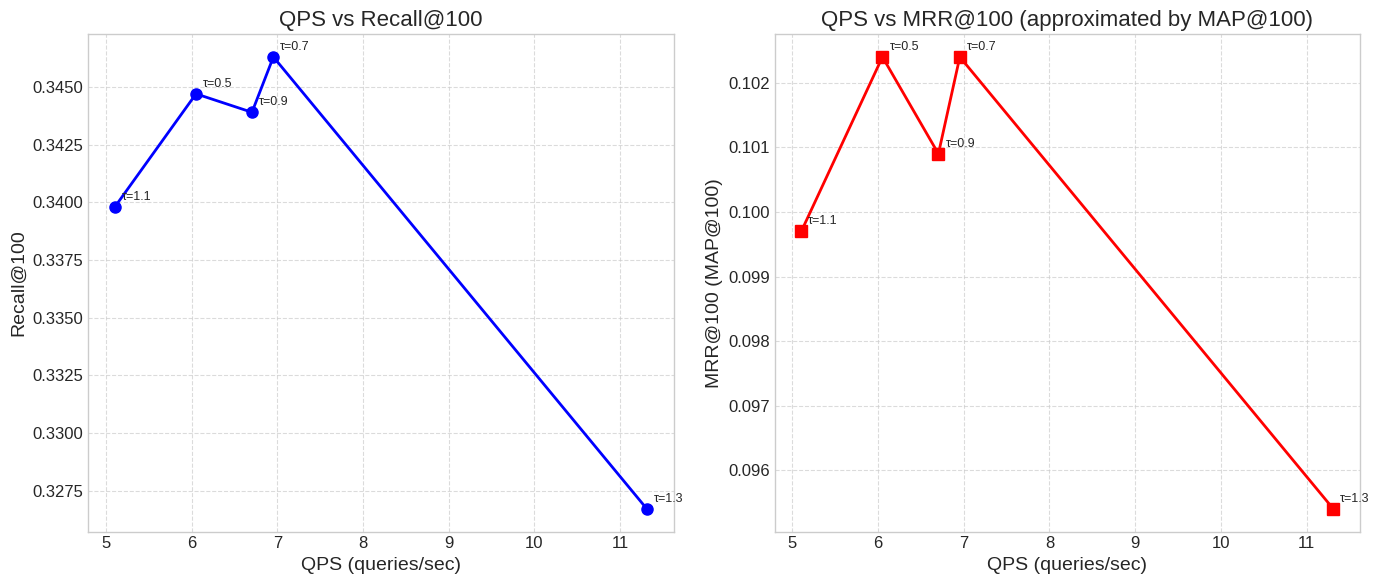

图片已保存为 '/data1/chenyifeng/MultiVector-Backup/dpr-scale/results/scidocs/summary.png'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

%matplotlib inline

csv_file = "/data1/chenyifeng/MultiVector-Backup/dpr-scale/results/scidocs/summary.csv"  
df = pd.read_csv(csv_file)

# 按 QPS 升序排序，使曲线连贯
df_sorted = df.sort_values("qps")

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12

# 创建两个子图，方便比较
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---------- 图1: QPS vs Recall@100 ----------
ax1.plot(df_sorted["qps"], df_sorted["recall_100"], marker='o', linestyle='-', linewidth=2, markersize=8, color='b')
ax1.set_xlabel("QPS (queries/sec)", fontsize=14)
ax1.set_ylabel("Recall@100", fontsize=14)
ax1.set_title("QPS vs Recall@100", fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.7)
# 标注每个点对应的 pruning_weight
for _, row in df_sorted.iterrows():
    ax1.annotate(f"τ={row['pruning_weight']}", 
                 xy=(row["qps"], row["recall_100"]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

# ---------- 图2: QPS vs MRR@100 (使用 MAP@100 代替) ----------
ax2.plot(df_sorted["qps"], df_sorted["map_100"], marker='s', linestyle='-', linewidth=2, markersize=8, color='r')
ax2.set_xlabel("QPS (queries/sec)", fontsize=14)
ax2.set_ylabel("MRR@100 (MAP@100)", fontsize=14)
ax2.set_title("QPS vs MRR@100 (approximated by MAP@100)", fontsize=16)
ax2.grid(True, linestyle='--', alpha=0.7)
for _, row in df_sorted.iterrows():
    ax2.annotate(f"τ={row['pruning_weight']}", 
                 xy=(row["qps"], row["map_100"]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
# --- 修改保存部分：与 CSV 同目录、同名（扩展名改为 .png） ---
output_dir = os.path.dirname(csv_file)
base_name = os.path.splitext(os.path.basename(csv_file))[0]
save_path = os.path.join(output_dir, base_name + ".png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"图片已保存为 '{save_path}'")